# Análisis de Calidad de Datos Simulados de Worker
El dataset "company_dataset.csv" que se van a analizar fue generado por la inteligencia artificial Claude.

### 0. Importaciones

In [30]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

### 1. Cargar Dataset

In [31]:
# Ajustar la ruta del archivo
from pathlib import Path

ROOT = Path().resolve().parents[0]
FILE_PATH = ROOT / "data" /"worker_dataset.csv"

workers = pd.read_csv(FILE_PATH)

print("Dataset cargado")
print(f"Filas    : {len(workers):,}")
print(f"Columnas : {len(workers.columns)}")
print("Vista previa:")
workers.head(10)

Dataset cargado
Filas    : 10,000
Columnas : 6
Vista previa:


,name,last_names,age,gender,group_index,rank_index
0,Javier,Valderrama López,26,Masculino,70,6
1,John,Barrera Ocampo,33,Masculino,160,4
2,Julia,Castro Sánchez,25,Femenino,240,6
3,María,González Jaimes,21,Masculino,523,6
4,María,Herrera Díaz,33,Masculino,138,5
5,Luz,Sánchez Jaramillo,25,Femenino,495,6
6,María,Hernández Leal,39,Femenino,679,8
7,Ovidio,Escobar Galeano,30,Masculino,247,8
8,Hernán,Quintero Rincón,31,Masculino,543,5
9,Dora,Gómez Bolaños,41,Femenino,524,3


In [32]:
# Tipos de datos detectados
print("Tipos de datos:")
print(workers.dtypes)
print("Info general:")
workers.info()

Tipos de datos:
name             str
last_names       str
age            int64
gender           str
group_index    int64
rank_index     int64
dtype: object
Info general:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         10000 non-null  str  
 1   last_names   10000 non-null  str  
 2   age          10000 non-null  int64
 3   gender       10000 non-null  str  
 4   group_index  10000 non-null  int64
 5   rank_index   10000 non-null  int64
dtypes: int64(3), str(3)
memory usage: 468.9 KB


### 2. Valores Nulos

In [33]:
# Si existen valores nulos, mostrar el conteo y porcentaje por columna
if workers.isnull().any().any(): 
    nulls = workers.isnull().sum().reset_index()
    nulls.columns = ["Columna", "Nulos"]

    # Filtrar columnas con nulos
    nulls = nulls[nulls["Nulos"] > 0]
    print("\nValores nulos:")
    print(nulls)

    # Calcular porcentaje
    nulls["Porcentaje (%)"] = (nulls["Nulos"] / len(workers) * 100).round(2)
    print("\nCon porcentaje:")
    print(nulls)

else: 
    print("No se encontraron valores nulos en el dataset.")

No se encontraron valores nulos en el dataset.


EL dataset creado no contiene nulls, sin embargo, en caso de que los tenga, debería realizarse una limpieza del dataset antes de hacer un análisis, ya que podría afectar el entrenamiento de datos de la IA.

### 3. Consistencia Lógica

In [34]:
print(workers["gender"].unique())

<StringArray>
['Masculino', 'Femenino', 'Prefiero no decir', 'No binario']
Length: 4, dtype: str


In [35]:
#Validar que no existan trabajadores menores de edad o mayores de 75 años
v1 = ((workers["age"] < 18 ) | (workers["age"] > 75)).sum()
print(f"Trabajadores menores de 18 o mayores de 75 años: {v1}")

# Validar que no existan valores negativos en las columnas numéricas
print ("\nValores negativos en columnas numéricas:")
for col in ["age", "group_index", "rank_index"]:
    print(f"{col}: {(workers[col] < 0).sum()} negativos")

# Validar que los valores en la columna "gender" sean válidos
valid_genders = ["Masculino", "Femenino", "Prefiero no decir", "No binario"]
invalid_gender = (~workers["gender"].isin(valid_genders)).sum()
if invalid_gender > 0:
    print(f"\nGéneros inválidos: {invalid_gender}")
    print("Valores únicos encontrados:", workers["gender"].unique())
else:
    print("\nTodos los géneros son válidos.")

# Validar que no hayan nombres vacíos o solo espacio es blanco en las columnas "name" y "last_name"
print("\nNombres vacíos:", (workers["name"].str.strip() == "").sum())
print("Apellidos vacíos:", (workers["last_names"].str.strip() == "").sum())

# Validar que no existan empleados duplicados en el dataset
print("\nFilas duplicadas:", workers.duplicated().sum())
print("Nombres duplicados:", workers.duplicated(subset=["name", "last_names"]).sum()) # Saber si hay empleados con el mismo nombre y apellido, aunque no sean la misma persona.
duplicados = workers[workers.duplicated(subset=["name", "last_names"], keep=False)]
print(duplicados.sort_values(["name", "last_names"]))

Trabajadores menores de 18 o mayores de 75 años: 0

Valores negativos en columnas numéricas:
age: 0 negativos
group_index: 0 negativos
rank_index: 0 negativos

Todos los géneros son válidos.

Nombres vacíos: 0
Apellidos vacíos: 0

Filas duplicadas: 0
Nombres duplicados: 21
          name          last_names  age             gender  group_index  \
955     Andrés      González Gómez   20          Masculino          261   
2815    Andrés      González Gómez   36          Masculino          548   
5736  Angélica    Rodríguez García   27          Masculino          793   
8764  Angélica    Rodríguez García   28         No binario          679   
3832     David          Rojas León   24           Femenino          633   
6402     David          Rojas León   34  Prefiero no decir          478   
1504     Edgar        López Correa   29           Femenino          758   
1581     Edgar        López Correa   19           Femenino          695   
306    Enrique     Morales Álvarez   26           F

A pesar de que hay personas con nombres y apellidos iguales, son personas diferentes, debido a que el resto de sus datos son diferentes, por lo que no hay duplicados. Dos o más personas pueden tener el mismo nombre completo, pero eso no significa que sean las mismas personas.

### 4. Distribución Estadística

In [36]:
# Estadísticas descriptivas para columnas numéricas
num_cols = ["age", "group_index", "rank_index"]

# Estadísticas descriptivas completas
stats_df = workers[num_cols].describe().T.round(2)
stats_df["sesgo"] = workers[num_cols].skew().round(3)
stats_df["CV (%)"] = (workers[num_cols].std() / workers[num_cols].mean() * 100).round(2) # coeficiente de variación
print(stats_df.to_string())

               count    mean     std   min    25%    50%    75%    max  sesgo  CV (%)
age          10000.0   30.09    7.66  18.0   24.0   30.0   35.0   64.0  0.715   25.45
group_index  10000.0  400.34  230.73   1.0  201.0  400.0  600.0  800.0 -0.004   57.63
rank_index   10000.0    5.24    1.65   1.0    4.0    5.0    6.0    8.0 -0.276   31.57


In [37]:
# Distribución por género
gender_dist = workers["gender"].value_counts()
gender_pct = workers["gender"].value_counts(normalize=True) * 100

print("\nDistribución por género:")
for g in gender_dist.index:
    print(f"  {g}: {gender_dist[g]:,} ({gender_pct[g]:.1f}%)")


Distribución por género:
  Masculino: 4,830 (48.3%)
  Femenino: 4,453 (44.5%)
  No binario: 416 (4.2%)
  Prefiero no decir: 301 (3.0%)


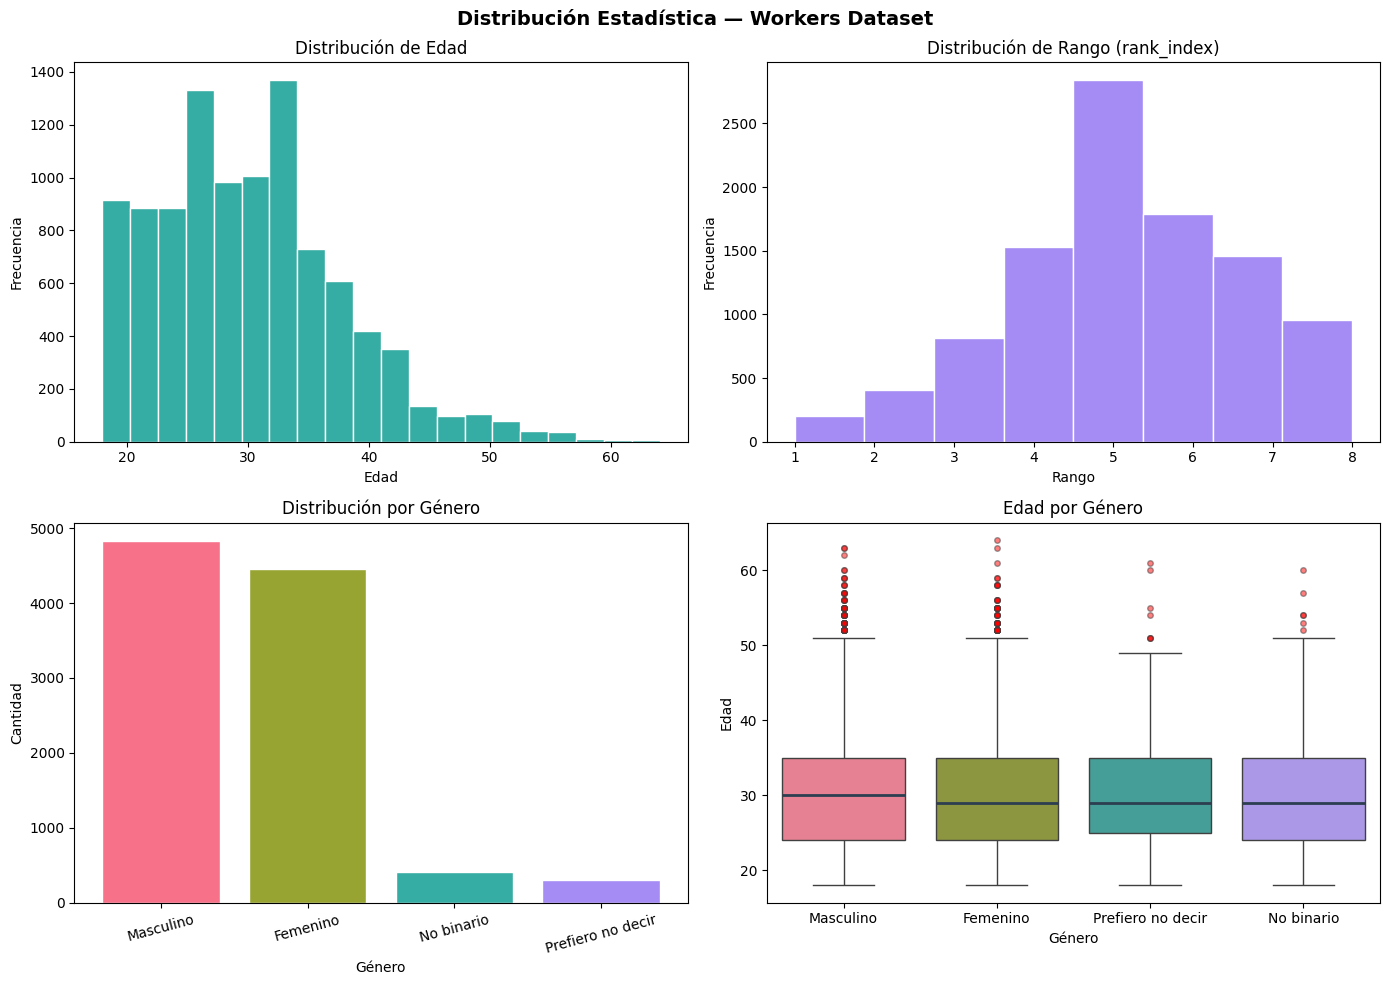

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribución Estadística — Workers Dataset", fontsize=14, fontweight="bold")

# Histograma de edad
axes[0, 0].hist(workers["age"], bins=20, color=sns.color_palette("husl", n_colors=4)[2], edgecolor="white")
axes[0, 0].set_title("Distribución de Edad")
axes[0, 0].set_xlabel("Edad")
axes[0, 0].set_ylabel("Frecuencia")

# Histograma de rank_index
axes[0, 1].hist(workers["rank_index"], bins=8, color=sns.color_palette("husl", n_colors=4)[3], edgecolor="white")
axes[0, 1].set_title("Distribución de Rango (rank_index)")
axes[0, 1].set_xlabel("Rango")
axes[0, 1].set_ylabel("Frecuencia")

# Distribución por género
gender_counts = workers["gender"].value_counts()
axes[1, 0].bar(gender_counts.index, gender_counts.values, color=sns.color_palette("husl", n_colors=4), edgecolor="white")
axes[1, 0].set_title("Distribución por Género")
axes[1, 0].set_xlabel("Género")
axes[1, 0].set_ylabel("Cantidad")
axes[1, 0].tick_params(axis="x", rotation=15)

# Boxplot edad por género
import seaborn as sns

sns.boxplot(
    data=workers,
    x="gender",
    y="age",
    ax=axes[1, 1],
    palette="husl",
    flierprops=dict(marker="o", markerfacecolor="red", markersize=4, alpha=0.5),
    medianprops=dict(color="#2c3e50", linewidth=2)
)

axes[1, 1].set_title("Edad por Género")
axes[1, 1].set_xlabel("Género")
axes[1, 1].set_ylabel("Edad")


plt.tight_layout()
plt.show()